# Pacotes

In [ ]:
!pip uninstall -y numpy
!pip uninstall -y setuptools
!pip install setuptools or conda install setuptools
!pip install bumpy or conda install numpy

Found existing installation: numpy 1.22.4
Uninstalling numpy-1.22.4:
  Successfully uninstalled numpy-1.22.4
Found existing installation: setuptools 63.4.3
Uninstalling setuptools-63.4.3:
  Successfully uninstalled setuptools-63.4.3
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.8 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement or (from versions: none)
ERROR: No matching distribution found for or
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package meta

In [ ]:
!pip install rasterio
!pip install rasterstats
!pip install osmnx

!pip uninstall matplotlib -y
!pip install matplotlib # ==3.1.3

!pip install bridson

! pip install haversine


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 61.2 MB/s eta 0:00:00
  Using cached setuptools-67.6.0-py3-none-any.whl (1.1 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 57.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.9.0 requires jedi>=0.10, which is not installed.
numba 0.56.4 requires numpy<1.24,>=1.18, but you have numpy 1.24.2 which is incompatible.
cvxpy 1.2.3 requires setuptools<=64.0.2, but you have setuptools 67.6.0 which is incompatible.
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.8/136.8 KB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 65.9 MB/s eta 0:00:00


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!pip uninstall -y numpy
!pip uninstall -y setuptools

!pip install numpy
!pip install setuptools




Found existing installation: numpy 1.24.2
Uninstalling numpy-1.24.2:
  Successfully uninstalled numpy-1.24.2
Found existing installation: setuptools 67.6.0
Uninstalling setuptools-67.6.0:
  Successfully uninstalled setuptools-67.6.0
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Using cached numpy-1.24.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.1.9 requires setuptools, which is not installed.
tensorflow 2.11.0 requires setuptools, which is not installed.
tensorboard 2.11.2 requires setuptools>=41.0.0, which is not installed.
spacy 3.4.4 requires setuptools, which is not installed.
rasterio 1.3.6 requires setuptools, which is not installed.
pandas-gbq 0.17.9 requires setuptools, which is not installed.
numba 0.56.4 requires setu

In [ ]:
import rasterio
from rasterio.plot import show
from rasterstats import  point_query
import geopandas
import osmnx as ox

from google.colab import drive
from google.colab import files

import matplotlib.pyplot as plt
#from matplotlib import _png
import pandas as pd

from bridson import poisson_disc_samples
import numpy as np
from shapely.geometry import Point
from shapely import wkt

#import haversine as hs
#from haversine import  Unit
import copy




In [ ]:
#!pip freeze

# Funções

In [ ]:
# Limpeza para pontos apenas dentro do município de Niterói

def Clear_Outbounds_Points_in_Polygon(polygon, pnts):

    points = []

    l = len(pnts)

    for i in range(l):
      if (polygon.contains(pnts[i])).bool():
            points.append(pnts[i])   
    return geopandas.GeoSeries(points)


In [ ]:
# Sorteio de coordenadas dentro do polígono

def Poisson_Disc_Random_Points_in_Polygon(polygon, radius_value):

    points = []

    minx = polygon.bounds.loc[0][0]
    miny = polygon.bounds.loc[0][1]
    maxx = polygon.bounds.loc[0][2]
    maxy = polygon.bounds.loc[0][3]

    width = maxx - minx
    height = maxy - miny

    pds = poisson_disc_samples(width=width,
                               height=height,
                               r= radius_value #(0.00125) aproximadamente 100 metros
                               )

    for i in range(len(pds)):
      pnt = Point(tuple(map(sum, zip(pds[i], (minx,miny)))))
      if (polygon.contains(pnt)).bool():
          points.append(pnt)

    return geopandas.GeoSeries(points)



```
hs.haversine((niteroi.bounds.loc[0][0],niteroi.bounds.loc[0][1]),
             (niteroi.bounds.loc[0][0],niteroi.bounds.loc[0][1]+0.0025),
             unit=Unit.METERS)
```



In [ ]:
#Distância mínima das ocorrências
def Suitable_Points_for_not_Occurence(points_disc_samples, points_occurence, radius ):

  aux1=[list((points_disc_samples[row_id].x,points_disc_samples[row_id].y)) for row_id in range(points_disc_samples.shape[0])]

  for i in range(len(points_occurence)):
    #print(f'')
    aux2=[]
    for j in range(len(aux1)):
      print(f'Amostra, {j} de {len(aux1)} - Ocorrência, {i} de {len(points_occurence)}')
      distancia = hs.haversine((points_occurence[i].x,points_occurence[i].y),
             aux1[j],
             unit=Unit.METERS)
      if distancia > radius:
        aux2.append(aux1[j])
    aux1 = copy.deepcopy(aux2)

  aux2=[]

  for i in range(len(aux1)):
    aux2.append(Point(aux1[i]))

  return geopandas.GeoSeries(aux2)

In [ ]:
# Criação de variáveis dicotômicas
def flg_func(value):
    if pd.isna(value):
        return 0
    else:
      return 1


# Conexão com a pasta

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/My Drive/PDPA

/content/drive/My Drive/PDPA


In [ ]:
#!ls

# Ocorrências

In [ ]:
ocorrencias = pd.read_csv('ocorrencias.csv'
                     ,sep = ','
                     ,decimal='.'
                      )

In [ ]:
gdf_ocorrencias = geopandas.GeoDataFrame(
    ocorrencias, geometry=geopandas.points_from_xy(x = ocorrencias.lon_ocr, y = ocorrencias.lat_ocr))

# Seleção do município de Niterói

In [ ]:
niteroi_q = "Niterói, Rio de Janeiro, Brazil"

In [ ]:
niteroi = ox.geocode_to_gdf(niteroi_q)

In [ ]:
del(niteroi_q)

In [ ]:
niteroi.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

# Seleção das coordenadas

## Com ocorrência

Limpeza para pontos apenas dentro do município de Niterói

In [ ]:
pts_c_ocorrencia = Clear_Outbounds_Points_in_Polygon(niteroi,gdf_ocorrencias.geometry)

In [ ]:
del(gdf_ocorrencias)

## Sem ocorrência

### Sorteio de coordenadas dentro de Niterói

In [ ]:
pts_s_ocorrencia = Poisson_Disc_Random_Points_in_Polygon(niteroi,(0.00125))  # Aproximadamente 50m de raio

### Retirar área de lagos

In [ ]:
gdf_pedologia = geopandas.read_file("pedo_area_mu_3303302.shp") 

In [ ]:
lagos = gdf_pedologia[gdf_pedologia.loc[:,'legenda' ] == 'Corpo d\'água continental'].unary_union

In [ ]:
l = len(pts_s_ocorrencia)
polygon = lagos
pnts = pts_s_ocorrencia
points = []

for i in range(l):
  if (polygon.contains(pnts[i])):
    continue
  else:  
    points.append(pnts[i]) 

In [ ]:
pts_s_ocorrencia = geopandas.GeoSeries(points)

### Retirar regiões a nível do mar

In [ ]:
pts_s_ocorrencia_lista=[list((pts_s_ocorrencia[row_id].x,pts_s_ocorrencia[row_id].y)) for row_id in range(pts_s_ocorrencia.shape[0])]

In [ ]:
df_s_ocorrencia = pd.DataFrame(pts_s_ocorrencia_lista, columns=['lon_ocr','lat_ocr'])
df_s_ocorrencia['geometry'] = pts_s_ocorrencia

In [ ]:
df_s_ocorrencia.loc[:,'Altitude_numerica']= point_query(df_s_ocorrencia.loc[:,'geometry'], '22S435ZN.tif')

/usr/local/lib/python3.8/dist-packages/rasterstats/io.py:313: UserWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn("Setting nodata to -999; specify nodata explicitly")


In [ ]:
print(min(df_s_ocorrencia['Altitude_numerica']))
print(max(df_s_ocorrencia['Altitude_numerica']))
print(np.mean(df_s_ocorrencia['Altitude_numerica']))

#https://pt-br.topographic-map.com/map-p5151/Niter%C3%B3i/?center=-22.90771%2C-43.10877&zoom=14

-1.0338838325091584
381.41144798126635
86.67734753993848


In [ ]:
df_s_ocorrencia_filt = df_s_ocorrencia[df_s_ocorrencia.loc[:,'Altitude_numerica' ] > 25]

In [ ]:
df_s_ocorrencia_filt

,lon_ocr,lat_ocr,geometry,Altitude_numerica
0,-43.088074,-22.988005,POINT (-43.08807 -22.98800),41.945662
1,-43.085710,-22.987795,POINT (-43.08571 -22.98780),84.946311
3,-43.084057,-22.986026,POINT (-43.08406 -22.98603),33.920711
4,-43.067260,-22.984866,POINT (-43.06726 -22.98487),52.628016
5,-43.065324,-22.984232,POINT (-43.06532 -22.98423),55.637476
...,...,...,...,...
3653,-43.092029,-22.864523,POINT (-43.09203 -22.86452),42.708781
3654,-43.088948,-22.864810,POINT (-43.08895 -22.86481),41.001755
3662,-43.089612,-22.863742,POINT (-43.08961 -22.86374),61.368945
3664,-43.085914,-22.863831,POINT (-43.08591 -22.86383),29.933824


In [ ]:
pts_s_ocorrencia_filt = geopandas.GeoSeries(list(df_s_ocorrencia_filt['geometry']))

### Seleção dos pontos aleatórios com distância mínima das ocorrências

In [ ]:
pts_s_ocorrencia_tratado = Suitable_Points_for_not_Occurence(pts_s_ocorrencia_filt, pts_c_ocorrencia,50)

Streaming output truncated to the last 5000 lines.
Amostra, 182 de 2591 - Ocorrência, 903 de 905
Amostra, 183 de 2591 - Ocorrência, 903 de 905
Amostra, 184 de 2591 - Ocorrência, 903 de 905
Amostra, 185 de 2591 - Ocorrência, 903 de 905
Amostra, 186 de 2591 - Ocorrência, 903 de 905
Amostra, 187 de 2591 - Ocorrência, 903 de 905
Amostra, 188 de 2591 - Ocorrência, 903 de 905
Amostra, 189 de 2591 - Ocorrência, 903 de 905
Amostra, 190 de 2591 - Ocorrência, 903 de 905
Amostra, 191 de 2591 - Ocorrência, 903 de 905
Amostra, 192 de 2591 - Ocorrência, 903 de 905
Amostra, 193 de 2591 - Ocorrência, 903 de 905
Amostra, 194 de 2591 - Ocorrência, 903 de 905
Amostra, 195 de 2591 - Ocorrência, 903 de 905
Amostra, 196 de 2591 - Ocorrência, 903 de 905
Amostra, 197 de 2591 - Ocorrência, 903 de 905
Amostra, 198 de 2591 - Ocorrência, 903 de 905
Amostra, 199 de 2591 - Ocorrência, 903 de 905
Amostra, 200 de 2591 - Ocorrência, 903 de 905
Amostra, 201 de 2591 - Ocorrência, 903 de 905
Amostra, 202 de 2591 - Ocorrê

In [ ]:
del(pts_s_ocorrencia)

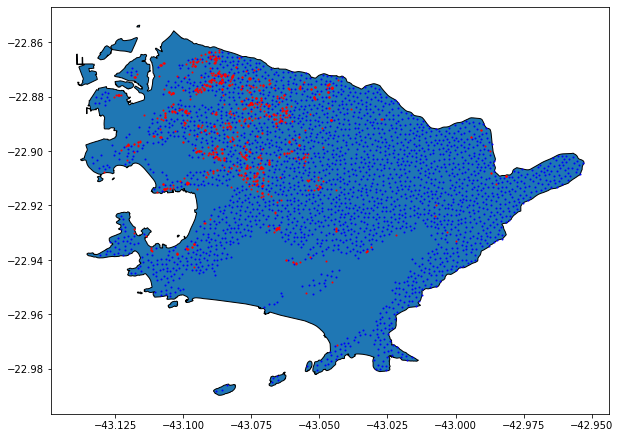

In [ ]:
base = niteroi.plot(linewidth=1, edgecolor="black", figsize = (10, 10))
pts_s_ocorrencia_tratado.plot(ax=base, linewidth=1, color="blue", markersize=1)
pts_c_ocorrencia.plot(ax=base, linewidth=1, color="red", markersize=1)
plt.show()

In [ ]:
del(base)
del(niteroi)

# Seleção das variáveis

In [ ]:
lista_arquivos_tif = ['22S435ZN.tif',
                      '22S435SN.tif',
                      '22S435ON.tif',
                      '22S435VN.tif',
                      '22S435HN.tif',
                      '22S435SA.tif',
                      '22S435SB.tif',
                      '22S435SC.tif',
                      '22S435OC.tif',
                      '22S435V3.tif',
                      '22S435V5.tif',
                      '22S435H3.tif',
                      '22S435H5.tif',
                      '22S435FT.tif',
                      '22S435RS.tif',
                      '22S435DD.tif']

In [ ]:
lista_nome_variaveis = ['Altitude_numerica',
                      'Declividade_numerica',
                      'Orientacao_numerica',
                      'Curv_Vertical_numerica',
                      'Curv_Horizontal_numerica',
                      'Declividade_classes_A',
                      'Declividade_classes_B',
                      'Declividade_classes_C',
                      'Orientacao_octantes',
                      'Curv_Vertical_3classes',
                      'Curv_Vertical_5classes',
                      'Curv_Horizontal_3classes',
                      'Curv_Horizontal_5classes',
                      'Forma_de_terreno_classes',
                      'Relevo_sombreado_numerico',
                      'ADD_divisores_talvegues']

# Organização do Data Frame Relevo


## Ocorrência

In [ ]:
df_ocorrencia = ocorrencias.loc[ocorrencias['geometry'].isin(pts_c_ocorrencia)]

In [ ]:
for variavel in range(len(lista_nome_variaveis)):
  df_ocorrencia.loc[:,lista_nome_variaveis[variavel]]= point_query(df_ocorrencia.loc[:,'geometry'], lista_arquivos_tif[variavel])

/usr/local/lib/python3.8/dist-packages/rasterstats/io.py:313: UserWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn("Setting nodata to -999; specify nodata explicitly")
<ipython-input-36-ba3e457a07b9>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ocorrencia.loc[:,lista_nome_variaveis[variavel]]= point_query(df_ocorrencia.loc[:,'geometry'], lista_arquivos_tif[variavel])
/usr/local/lib/python3.8/dist-packages/rasterstats/io.py:313: UserWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn("Setting nodata to -999; specify nodata explicitly")
<ipython-input-36-ba3e457a07b9>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

In [ ]:
del(ocorrencias)
del(pts_c_ocorrencia)

## Sem ocorrência

In [ ]:
pts_s_ocorrencia_lista=[list((pts_s_ocorrencia_tratado[row_id].x,pts_s_ocorrencia_tratado[row_id].y)) for row_id in range(pts_s_ocorrencia_tratado.shape[0])]

In [ ]:
df_s_ocorrencia = pd.DataFrame(pts_s_ocorrencia_lista, columns=['lon_ocr','lat_ocr'])

In [ ]:
df_s_ocorrencia['geometry'] = pts_s_ocorrencia_tratado

In [ ]:
for variavel in range(len(lista_nome_variaveis)):
  df_s_ocorrencia.loc[:,lista_nome_variaveis[variavel]]= point_query(df_s_ocorrencia.loc[:,'geometry'], lista_arquivos_tif[variavel])

/usr/local/lib/python3.8/dist-packages/rasterstats/io.py:313: UserWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn("Setting nodata to -999; specify nodata explicitly")
/usr/local/lib/python3.8/dist-packages/rasterstats/io.py:313: UserWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn("Setting nodata to -999; specify nodata explicitly")
/usr/local/lib/python3.8/dist-packages/rasterstats/io.py:313: UserWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn("Setting nodata to -999; specify nodata explicitly")
/usr/local/lib/python3.8/dist-packages/rasterstats/io.py:313: UserWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn("Setting nodata to -999; specify nodata explicitly")
/usr/local/lib/python3.8/dist-packages/rasterstats/io.py:313: UserWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn("Setting nodata to -999; specify nodata explicitly")
/usr/local/lib/python3.8/dist-

In [ ]:
del(lista_arquivos_tif)
del(lista_nome_variaveis)
del(pts_s_ocorrencia_lista)
del(pts_s_ocorrencia_tratado)
del(variavel)

# Arquivo Relevo

In [ ]:
df_relevo = pd.concat([df_s_ocorrencia, df_ocorrencia], ignore_index=True)

In [ ]:
del(df_s_ocorrencia)
del(df_ocorrencia)

In [ ]:
df_relevo.to_csv('informacoes_relevo_100m.csv',index=False, encoding = 'utf-8-sig') 
files.download('informacoes_relevo_100m.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_relevo = pd.read_csv('informacoes_relevo_100m.csv'
                     ,sep = ','
                     ,decimal='.'
                      )

In [ ]:
df_relevo['n_coord'] = range(0,len(df_relevo))

In [ ]:
df_relevo['geometry'] = df_relevo['geometry'].apply(wkt.loads)
gdf_relevo = geopandas.GeoDataFrame(df_relevo, crs='epsg:4326')

# Informação de vegetação

In [ ]:
gdf_vegetacao = geopandas.read_file("vege_area_mu_3303302.shp").to_crs(4326)  

In [ ]:
gdf_relevo_veg = geopandas.tools.sjoin(gdf_relevo, gdf_vegetacao[['leg_sup','legenda_1','legenda_2','geometry']], predicate="within", how='left')

In [ ]:
_dummies = pd.get_dummies(gdf_relevo_veg, columns = None, drop_first = False)

In [ ]:
#pd.set_option('display.max_columns', None)

In [ ]:
_dummies = _dummies.rename(columns={"	leg_sup_Massa D´água": "Massa_Dagua"
                            , "leg_sup_Vegetação Natural Dominante": "Vegetacao_Natural_Dominante"
                            , "leg_sup_Área Antrópica Dominante": "Area_Antropica_Dominante"
                            , "legenda_1_Floresta Ombrófila Densa": "Floresta_Ombrofila_Densa"
                            , "legenda_1_Formação Pioneira": "Formacao_Pioneira"
                            , "legenda_2_Floresta Ombrófila Densa Submontana": "Floresta_Ombrofila_Densa_Submontana"
                            , "legenda_2_Formação Pioneira com influência fluviomarinha": "Formacao_Pioneira_com_influencia_fluviomarinha"
                            , "legenda_2_Influência urbana": "Influencia_urbana"
                            , "legenda_2_Vegetação Secundária": "Vegetacao_Secundaria"}).drop(["index_right", "legenda_2_Indiscriminada"], axis=1)

In [ ]:
gdf_relevo = copy.deepcopy(_dummies)

In [ ]:
del(gdf_relevo_veg); del(gdf_vegetacao); del(_dummies)

# Informação de Pedologia

In [ ]:
gdf_pedologia = geopandas.read_file("pedo_area_mu_3303302.shp").to_crs(4326)

In [ ]:
gdf_relevo_ped = geopandas.tools.sjoin(gdf_relevo, gdf_pedologia[['leg_ordem','legenda_2','geometry']], predicate="within", how='left')

In [ ]:
_dummies = pd.get_dummies(gdf_relevo_ped, columns = None, drop_first = False)

In [ ]:
#pd.set_option('display.max_columns', None)

In [ ]:
_dummies = _dummies.rename(columns={"leg_ordem_ARGISSOLO": "Argilossolo"
                            , "leg_ordem_GLEISSOLO": "Gleissolo"
                            , "legenda_2_ARGISSOLO AMARELO": "Argilossolo_Amarelo"
                            , "legenda_2_ARGISSOLO VERMELHO-AMARELO": "Argilossolo_Vermelho_Amarelo"
                            , "legenda_2_GLEISSOLO MELÂNICO": "Gleissolo_Melanico"
                            , "legenda_2_ÁREA URBANA": "Area_Urbana"}).drop(["index_right","leg_ordem_OUTROS"], axis=1)

In [ ]:
gdf_relevo = copy.deepcopy(_dummies)

In [ ]:
del(gdf_relevo_ped); del(gdf_pedologia); del(_dummies)

# Unidade de Conservação

In [ ]:
gdf_u_conservacao = geopandas.read_file('Unidades_de_Conservacao_Integral.geojson')

In [ ]:
DR = gdf_u_conservacao.iloc[[3]]
ST = gdf_u_conservacao.iloc[[4]]
res_difference = DR.overlay(ST, how='difference')


In [ ]:
gdf_u_conservacao = pd.concat([gdf_u_conservacao, res_difference])
gdf_u_conservacao = gdf_u_conservacao.drop(3, axis=0)

In [ ]:
gdf_relevo_conservacao = geopandas.tools.sjoin(gdf_relevo, gdf_u_conservacao[['tx_tipounidade','tx_planmanejo','geometry']], predicate="within", how='left').drop_duplicates()

In [ ]:
_dummies = pd.get_dummies(gdf_relevo_conservacao, columns = None, drop_first = False)

In [ ]:
#pd.set_option('display.max_columns', None)

In [ ]:
_dummies = _dummies.rename(columns={"tx_tipounidade_Proteção Integral": "Unidades_de_Conservacao_Protecao_Integral"
                            , "tx_tipounidade_ ": "Unidades_de_Conservacao_Protecao_N_Integral"
                            , "tx_planmanejo_SIM": "Plano_de_Manejo"
                            , "tx_planmanejo_NÃO": "Sem_Plano_de_Menejo"}).drop(["index_right"], axis=1).drop_duplicates()

In [ ]:
gdf_relevo = copy.deepcopy(_dummies)

In [ ]:
del(gdf_u_conservacao); del(DR); del(ST); del(res_difference); del(gdf_relevo_conservacao); del(_dummies)

# Informação de Comunidades

In [ ]:
gdf_comunidades = geopandas.read_file('Comunidades.geojson')

In [ ]:
#gdf_comunidades.crs
#gdf_comunidades

In [ ]:
gdf_relevo_comunidades = geopandas.tools.sjoin(gdf_relevo, gdf_comunidades, predicate="within", how='left')

In [ ]:
gdf_relevo_comunidades['flg_comunidades'] = gdf_relevo_comunidades['OBJECTID'].map(flg_func)

In [ ]:
gdf_relevo_comunidades = gdf_relevo_comunidades.drop(columns=['index_right','OBJECTID','Nome','Area_ha'])

In [ ]:
del(gdf_comunidades)

# Informações de uso de solo

In [ ]:
gdf = gdf_relevo_comunidades

In [ ]:
variaveis_us = ['agricola'
                ,'exploracao_mineral'
                ,'corpo_hidrico'
                ,'rocha'
                ,'cobertura_vegetal'
                ,'afloramento_rochoso'
                ,'favela'
                ,'ocupacao_desordenada']

In [ ]:
for variavel in variaveis_us:

  gdf_uso_solo = geopandas.read_file('Uso_do_solo_' + variavel + '.geojson')

  gdf = geopandas.tools.sjoin(gdf, gdf_uso_solo, predicate="within", how='left')

  gdf['flg_'+ variavel] = gdf['OBJECTID_1'].map(flg_func)

  gdf = gdf.drop(columns=['index_right','OBJECTID_1','Nome','Código','Área','comparacao','Uso_do_Sol','Nome_1','OBS_1','OBS_12','Observacao','OBS','Observ']).drop_duplicates()


In [ ]:
del(gdf_uso_solo)

# Informação de área de risco

In [ ]:
gdf_risco = geopandas.read_file('areas_de_risco_Defesa_Civil.geojson')

gdf = geopandas.tools.sjoin(gdf, gdf_risco, predicate="within", how='left')

gdf['flg_areas_de_risco'] = gdf['OBJECTID'].map(flg_func)

gdf = gdf.drop(columns=['index_right','OBJECTID','tx_localid'])

In [ ]:
gdf['graurisc'] = gdf['graurisc'].transform(lambda x: x.fillna(0))

In [ ]:
gdf = pd.get_dummies(gdf,prefix_sep='_', columns=['Acoes_DC'])

# Especificar estação para coordenadas

In [ ]:
df_voronoi = pd.read_csv('voronoi_prefeitura.csv'
                     ,sep = ','
                     ,decimal='.'
                      )

In [ ]:
df_voronoi['geometry'] = df_voronoi['geom'].apply(wkt.loads)
gdf_voronoi = geopandas.GeoDataFrame(df_voronoi, crs='epsg:4326').drop_duplicates() #id 521, que é o Piratininga 2

In [ ]:
pointInPolys = geopandas.tools.sjoin(gdf, gdf_voronoi, predicate="within", how='left')

In [ ]:
# Registros sem ocorrência
pointInPolys_s_o = pointInPolys[pointInPolys.loc[:,'id_tempo'].isnull()]

In [ ]:
# Registros com ocorrência
pointInPolys_c_o = pointInPolys[pointInPolys.loc[:,'id_tempo'].notnull()]

In [ ]:
#list(np.unique(pointInPolys[['id_estacao']]))

# Espaços no tempo

O menor horário com ocorrência é id_tempo 117049888, analisar chuva diária (lag 24*60)

In [ ]:
lag = 24*60

In [ ]:
list(range(13087261,  13228382, lag ))

[13087261,
 13088701,
 13090141,
 13091581,
 13093021,
 13094461,
 13095901,
 13097341,
 13098781,
 13100221,
 13101661,
 13103101,
 13104541,
 13105981,
 13107421,
 13108861,
 13110301,
 13111741,
 13113181,
 13114621,
 13116061,
 13117501,
 13118941,
 13120381,
 13121821,
 13123261,
 13124701,
 13126141,
 13127581,
 13129021,
 13130461,
 13131901,
 13133341,
 13134781,
 13136221,
 13137661,
 13139101,
 13140541,
 13141981,
 13143421,
 13144861,
 13146301,
 13147741,
 13149181,
 13150621,
 13152061,
 13153501,
 13154941,
 13156381,
 13157821,
 13159261,
 13160701,
 13162141,
 13163581,
 13165021,
 13166461,
 13167901,
 13169341,
 13170781,
 13172221,
 13173661,
 13175101,
 13176541,
 13177981,
 13179421,
 13180861,
 13182301,
 13183741,
 13185181,
 13186621,
 13188061,
 13189501,
 13190941,
 13192381,
 13193821,
 13195261,
 13196701,
 13198141,
 13199581,
 13201021,
 13202461,
 13203901,
 13205341,
 13206781,
 13208221,
 13209661,
 13211101,
 13212541,
 13213981,
 13215421,
 13216861,

In [ ]:
pd.set_option('display.max_rows', 5)

# Informações de chuva

In [ ]:
df_chuva = pd.read_csv('Tempo_estacao_24h.csv'
                     ,sep = ','
                     ,decimal='.'
                     ,encoding = 'utf-8'
                      )

In [ ]:
#pd.set_option('display.max_columns', None)

In [ ]:
df_chuva = df_chuva.merge( pointInPolys.drop(columns=['Acoes_DC_0', 'flg_corpo_hidrico',	'Acoes_DC_1',	'Acoes_DC_2',	'Acoes_DC_3','index_right','lat','long','geom','Sem_Plano_de_Menejo']),
                                   right_on=['id_estacao'],
                                   left_on=['id_estacao'],
                                   how='inner')

In [ ]:
# id_tempo_y - Tempo da solicitação
# id_tempo_x - Tempo da série temporal a ser analisada

df_chuva['ocorrencia'] = 0
_ocorrencia = (((df_chuva.loc[:,'id_tempo_x' ]- 24 * 60) < (df_chuva.loc[:,'id_tempo_y'] )) &  ((df_chuva.loc[:,'id_tempo_x' ]) >= (df_chuva.loc[:,'id_tempo_y'] )))
df_chuva.loc[_ocorrencia,'ocorrencia'] = 1

In [ ]:
df_chuva = df_chuva.drop(columns=['id_estacao', 'id_solicitacao',	'id_tempo_y']).drop_duplicates()

In [ ]:
#sum(df_chuva['ocorrencia'])

In [ ]:
df_chuva

,id_tempo_x,tempo,vintequatrohoras,lon_ocr,lat_ocr,geometry,Altitude_numerica,Declividade_numerica,Orientacao_numerica,Curv_Vertical_numerica,...,flg_agricola,flg_exploracao_mineral,flg_rocha,flg_cobertura_vegetal,flg_afloramento_rochoso,flg_favela,flg_ocupacao_desordenada,graurisc,flg_areas_de_risco,ocorrencia
0,12259261,2020-04-23 09:00:00.000,0.0,-43.067260,-22.984866,POINT (-43.06726 -22.98487),52.628016,42.146139,196.168080,0.058848,...,0,0,0,1,0,0,0,0,0,0
1,12259261,2020-04-23 09:00:00.000,0.0,-43.065324,-22.984232,POINT (-43.06532 -22.98423),55.637476,52.919407,136.028123,0.066820,...,0,0,0,1,0,0,0,0,0,0
2,12259261,2020-04-23 09:00:00.000,0.0,-43.066912,-22.983404,POINT (-43.06691 -22.98340),49.241599,47.213131,331.520808,0.024909,...,0,0,0,1,0,0,0,0,0,0
3,12259261,2020-04-23 09:00:00.000,0.0,-43.065536,-22.982592,POINT (-43.06554 -22.98259),25.035910,60.529638,345.671957,-0.050607,...,0,0,0,1,0,0,0,0,0,0
4,12259261,2020-04-23 09:00:00.000,0.0,-43.050843,-22.980390,POINT (-43.05084 -22.98039),58.199686,59.218003,180.583131,-0.027040,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3270132,11930941,2019-09-08 09:00:00.000,0.0,-43.088680,-22.866286,POINT (-43.08868 -22.86629),41.686992,19.333016,227.936235,0.001986,...,0,0,0,0,0,1,0,0,0,0
3270133,11930941,2019-09-08 09:00:00.000,0.0,-43.087010,-22.863764,POINT (-43.08701 -22.86376),22.700953,7.579710,287.522159,-0.035597,...,0,0,0,0,0,0,0,0,0,0
3270134,11930941,2019-09-08 09:00:00.000,0.0,-43.088237,-22.865197,POINT (-43.08824 -22.86520),41.149896,23.492708,340.243524,-0.017163,...,0,0,0,0,0,1,0,0,0,0
3270135,11930941,2019-09-08 09:00:00.000,0.0,-43.087003,-22.862870,POINT (-43.08700 -22.86287),25.621156,2.169984,249.780773,-0.003414,...,0,0,0,0,0,0,0,0,0,0


# DataFrame final

In [ ]:
df_final = df_chuva[['n_coord'
,'ocorrencia'
,'lon_ocr'
,'lat_ocr'
,'id_tempo_x' 
,'tempo'                              
 ,'vintequatrohoras'                                                                                                
 ,'Altitude_numerica'        
 ,'Declividade_numerica'     
 ,'Orientacao_numerica'      
 ,'Curv_Vertical_numerica'   
 ,'Curv_Horizontal_numerica' 
 ,'Declividade_classes_A'    
 ,'Declividade_classes_B'    
 ,'Declividade_classes_C'    
 ,'Orientacao_octantes'      
 ,'Curv_Vertical_3classes'   
 ,'Curv_Vertical_5classes'   
 ,'Curv_Horizontal_3classes' 
 ,'Curv_Horizontal_5classes' 
 ,'Forma_de_terreno_classes' 
 ,'Relevo_sombreado_numerico'
 ,'ADD_divisores_talvegues'
 ,'Vegetacao_Natural_Dominante'	
,'Area_Antropica_Dominante'	
,'legenda_2_Pecuária (pastagens)'
,'Floresta_Ombrofila_Densa'	
,'Formacao_Pioneira'	
,'Floresta_Ombrofila_Densa_Submontana'	
,'Influencia_urbana'	
,'Vegetacao_Secundaria'	
,'Argilossolo'
,'Gleissolo'	
,'Argilossolo_Vermelho_Amarelo'	
,'Gleissolo_Melanico'	
,'Area_Urbana'	
,'Unidades_de_Conservacao_Protecao_N_Integral'	
,'Unidades_de_Conservacao_Protecao_Integral'	
,'Plano_de_Manejo'
 ,'flg_comunidades'
 ,'flg_agricola'
 ,'flg_exploracao_mineral'
 ,'flg_rocha'
 ,'flg_cobertura_vegetal'
 ,'flg_afloramento_rochoso'
 ,'flg_favela'
 ,'flg_ocupacao_desordenada'
 ,'flg_areas_de_risco'
 ,'graurisc']]

In [ ]:
df_final

,n_coord,ocorrencia,lon_ocr,lat_ocr,id_tempo_x,tempo,vintequatrohoras,Altitude_numerica,Declividade_numerica,Orientacao_numerica,...,flg_comunidades,flg_agricola,flg_exploracao_mineral,flg_rocha,flg_cobertura_vegetal,flg_afloramento_rochoso,flg_favela,flg_ocupacao_desordenada,flg_areas_de_risco,graurisc
0,3,0,-43.067260,-22.984866,12259261,2020-04-23 09:00:00.000,0.0,52.628016,42.146139,196.168080,...,0,0,0,0,1,0,0,0,0,0
1,4,0,-43.065324,-22.984232,12259261,2020-04-23 09:00:00.000,0.0,55.637476,52.919407,136.028123,...,0,0,0,0,1,0,0,0,0,0
2,5,0,-43.066912,-22.983404,12259261,2020-04-23 09:00:00.000,0.0,49.241599,47.213131,331.520808,...,0,0,0,0,1,0,0,0,0,0
3,6,0,-43.065536,-22.982592,12259261,2020-04-23 09:00:00.000,0.0,25.035910,60.529638,345.671957,...,0,0,0,0,1,0,0,0,0,0
4,7,0,-43.050843,-22.980390,12259261,2020-04-23 09:00:00.000,0.0,58.199686,59.218003,180.583131,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3270132,3422,0,-43.088680,-22.866286,11930941,2019-09-08 09:00:00.000,0.0,41.686992,19.333016,227.936235,...,1,0,0,0,0,0,1,0,0,0
3270133,3455,0,-43.087010,-22.863764,11930941,2019-09-08 09:00:00.000,0.0,22.700953,7.579710,287.522159,...,0,0,0,0,0,0,0,0,0,0
3270134,3466,0,-43.088237,-22.865197,11930941,2019-09-08 09:00:00.000,0.0,41.149896,23.492708,340.243524,...,1,0,0,0,0,0,1,0,0,0
3270135,3489,0,-43.087003,-22.862870,11930941,2019-09-08 09:00:00.000,0.0,25.621156,2.169984,249.780773,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
del(df_chuva)
del(df_relevo)
del(gdf_relevo)
del(df_voronoi)
del(gdf_voronoi)
del(pointInPolys)

# Salvar DataFrame final

In [ ]:
df_final.to_csv('df_final.csv',index=False, encoding = 'utf-8-sig') 
files.download('df_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>